# Robustness-Aware Smishing Detection
### Comparative Evaluation of Transformer Models Under Layered Adversarial Attacks

**Goal**: Evaluate RoBERTa, XLM-RoBERTa, DeBERTa, and DistilBERT against Unicode Homoglyph and Invisible Character attacks, then test a 3-step Reconstruction Defense.

In [1]:
import os, re, gc, time, unicodedata, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from tqdm.auto import tqdm
import Levenshtein

warnings.filterwarnings('ignore')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 3050 Laptop GPU
VRAM: 4.0 GB


## 1. Data Preprocessing

In [2]:
# 1.1 Load Dataset
df = pd.read_csv('Combined-Labeled-Dataset.csv')
df = df[['message', 'smishing label']].rename(columns={'smishing label': 'label'})

# 1.2 Deduplication
initial_len = len(df)
df.drop_duplicates(subset=['message'], inplace=True)
print(f"Removed {initial_len - len(df)} duplicate messages.")

# 1.3 Unicode Normalization (NFKC)
df['message'] = df['message'].apply(lambda x: unicodedata.normalize('NFKC', str(x)))

# 1.4 Stratified Split (80/10/10)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['label'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Removed 10280 duplicate messages.
Train: 59666, Val: 7458, Test: 7459


### 1.5 Dataset Exploratory Data Analysis (EDA)

In [ ]:
# Calculate EDA Statistics
total_messages = len(df)
ham_count = len(df[df['label'] == 0])
smishing_count = len(df[df['label'] == 1])
ham_pct = (ham_count / total_messages) * 100
smishing_pct = (smishing_count / total_messages) * 100

df['char_len'] = df['message'].apply(len)
df['word_len'] = df['message'].apply(lambda x: len(str(x).split()))

avg_char_ham = df[df['label'] == 0]['char_len'].mean()
avg_char_smish = df[df['label'] == 1]['char_len'].mean()
avg_word_ham = df[df['label'] == 0]['word_len'].mean()
avg_word_smish = df[df['label'] == 1]['word_len'].mean()

print("=== DATASET STATISTICS TABLE ===")
eda_table = pd.DataFrame({
    'Metric': [
        'Total Messages (Cleaned)', 
        'Ham Messages (Label 0)', 
        'Smishing Messages (Label 1)',
        'Avg Message Length (Characters) - Ham',
        'Avg Message Length (Characters) - Smishing',
        'Avg Message Length (Words) - Ham',
        'Avg Message Length (Words) - Smishing'
    ],
    'Value': [
        f"{total_messages:,}",
        f"{ham_count:,} ({ham_pct:.2f}%)",
        f"{smishing_count:,} ({smishing_pct:.2f}%)",
        f"{avg_char_ham:.2f}",
        f"{avg_char_smish:.2f}",
        f"{avg_word_ham:.2f}",
        f"{avg_word_smish:.2f}"
    ]
})
print(eda_table.to_string(index=False))

# Clean up temp EDA columns biar tidak mempengaruhi faktor lainnya
df.drop(columns=['char_len', 'word_len'], inplace=True)

=== DATASET STATISTICS TABLE ===
                                    Metric           Value
                  Total Messages (Cleaned)          74,583
                    Ham Messages (Label 0) 51,665 (69.27%)
               Smishing Messages (Label 1) 22,918 (30.73%)
     Avg Message Length (Characters) - Ham           76.20
Avg Message Length (Characters) - Smishing          149.73
          Avg Message Length (Words) - Ham           14.37
     Avg Message Length (Words) - Smishing           24.63


## 2. Adversarial Attack Simulation

In [ ]:
class AdversarialAttacker:
    def __init__(self):
        # Homoglyph map: Latin char -> Unicode yang kelihatan sama secara visual
        # Menggunakan kode heksadesimal chr()
        self.homoglyph_map = {
            'a': chr(0x0430),  # Cyrillic а
            'c': chr(0x0441),  # Cyrillic с
            'e': chr(0x0435),  # Cyrillic е
            'h': chr(0x04BB),  # Cyrillic һ
            'i': chr(0x0456),  # Cyrillic і
            'j': chr(0x0458),  # Cyrillic ј
            'k': chr(0x03BA),  # Greek κ
            'l': chr(0x04CF),  # Cyrillic ӏ
            'o': chr(0x043E),  # Cyrillic о
            'p': chr(0x0440),  # Cyrillic р
            'r': chr(0x0433),  # Cyrillic г
            's': chr(0x0455),  # Cyrillic ѕ
            'u': chr(0x03C5),  # Greek υ
            'v': chr(0x03BD),  # Greek ν
            'x': chr(0x0445),  # Cyrillic х
            'y': chr(0x0443),  # Cyrillic у
        }
        # Invisible zero-width characters (beneran invisible di outputnya)
        self.invisible_chars = [
            '\u200B',  # Zero-Width Space
            '\u200C',  # Zero-Width Non-Joiner
            '\u200D',  # Zero-Width Joiner
            '\uFEFF',  # Zero-Width No-Break Space (BOM)
        ]

    def apply_homoglyph(self, text, prob=0.2):
        return ''.join(
            self.homoglyph_map.get(c.lower(), c) if np.random.rand() < prob else c
            for c in text
        )

    def apply_invisible(self, text, prob=0.1):
        res = []
        for c in text:
            res.append(c)
            if np.random.rand() < prob:
                res.append(np.random.choice(self.invisible_chars))
        return ''.join(res)

    def apply_layered(self, text, prob=0.2):
        text = self.apply_homoglyph(text, prob)
        text = self.apply_invisible(text, prob)
        return text

attacker = AdversarialAttacker()
np.random.seed(42)  # Reproducible demo
sample = 'Please click this link to verify your account: http://bit.ly/secure'

# Show all 3 tiers 
tier1_homo   = attacker.apply_homoglyph(sample)
np.random.seed(42)
tier1_invis  = attacker.apply_invisible(sample)
np.random.seed(42)
tier2_layered = attacker.apply_layered(sample)

print('='*70)
print('TIER 0 — ORIGINAL (clean text):')
print(f'  {sample}')
print()
print('TIER 1a — HOMOGLYPH ONLY (some Latin letters swapped to Cyrillic/Greek):')
print(f'  {tier1_homo}')
print('  ^ Looks identical, but some letters are fake Unicode lookalikes!')
print()
print('TIER 1b — INVISIBLE ONLY (zero-width chars injected between letters):')
print(f'  {tier1_invis}')
print(f'  ^ Looks identical, but has {len(tier1_invis) - len(sample)} hidden chars inserted!')
print()
print('TIER 2  — LAYERED (both homoglyphs AND invisible chars combined):')
print(f'  {tier2_layered}')
print('='*70)

# How to detect: show repr() and codepoints 
print()
print('HOW TO DETECT THE FAKES:')
print('-'*70)
print('Compare character-by-character between original and attacked text.')
print('Example — the word "click":')
orig_word = 'click'
attacked_word = attacker.apply_homoglyph('click', prob=1.0)  # force all
for i, (o, a) in enumerate(zip(orig_word, attacked_word)):
    match = 'SAME' if o == a else 'FAKE'
    print(f'  Position {i}: original={o!r} (U+{ord(o):04X})  vs  attacked={a!r} (U+{ord(a):04X})  [{match}]')
print()
print('The letters look the same visually, but have different Unicode codepoints.')
print('This is how adversarial homoglyph attacks bypass NLP classifiers.')

TIER 0 — ORIGINAL (clean text):
  Please click this link to verify your account: http://bit.ly/secure

TIER 1a — HOMOGLYPH ONLY (some Latin letters swapped to Cyrillic/Greek):
  Pleaѕе cliсk tһіs linκ to νerіfу your acсoυnt: http://bit.ӏy/securе
  ^ Looks identical, but some letters are fake Unicode lookalikes!

TIER 1b — INVISIBLE ONLY (zero-width chars injected between letters):
  Please ﻿clic﻿k this link to ver‍ify​ you﻿r account: h‌ttp://‍bit.ly/secur​e
  ^ Looks identical, but has 8 hidden chars inserted!

TIER 2  — LAYERED (both homoglyphs AND invisible chars combined):
  Pl‍eaѕе‍ cli‍сk tһ‍іs linκ‌ to ν‍er​іfу yo‍ur a‍cсoυn﻿t:‌ ht​tp​:/​/b﻿it.ӏy/﻿securе

HOW TO DETECT THE FAKES:
----------------------------------------------------------------------
Compare character-by-character between original and attacked text.
Example — the word "click":
  Position 0: original='c' (U+0063)  vs  attacked='с' (U+0441)  [FAKE]
  Position 1: original='l' (U+006C)  vs  attacked='ӏ' (U+04CF)  [FAK

## 3. Defense Module

In [5]:
class CharacterReconstruction:
    def __init__(self, homoglyph_map):
        self.reverse_map = {v: k for k, v in homoglyph_map.items()}
        self.invisible_chars = [
            '\u200B', '\u200C', '\u200D', '\uFEFF'
        ]

    def reconstruct(self, text):
        # Step 1: Strip invisible characters
        for char in self.invisible_chars:
            text = text.replace(char, '')
        # Step 2: NFKC normalization
        text = unicodedata.normalize('NFKC', text)
        # Step 3: Reverse homoglyph substitution
        res = []
        for c in text:
            res.append(self.reverse_map.get(c, c))
        return ''.join(res)

defense = CharacterReconstruction(attacker.homoglyph_map)
attacked_sample = tier2_layered
reconstructed = defense.reconstruct(attacked_sample)

print('DEFENSE MODULE DEMONSTRATION')
print('='*70)
print(f'Original:      {sample}')
print(f'Attacked:      {attacked_sample}')
print(f'Reconstructed: {reconstructed}')
rss = 1 - Levenshtein.distance(reconstructed, sample) / max(len(reconstructed), len(sample))
print(f'RSS Score:     {rss:.4f}')
print(f'Match:         {"PERFECT" if reconstructed == sample else "PARTIAL"}')

DEFENSE MODULE DEMONSTRATION
Original:      Please click this link to verify your account: http://bit.ly/secure
Attacked:      Pl‍eaѕе‍ cli‍сk tһ‍іs linκ‌ to ν‍er​іfу yo‍ur a‍cсoυn﻿t:‌ ht​tp​:/​/b﻿it.ӏy/﻿securе
Reconstructed: Please click this link to verify your account: http://bit.ly/secure
RSS Score:     1.0000
Match:         PERFECT


## 4. Model Training

In [6]:
import os
os.makedirs('saved_models/roberta', exist_ok=True)
os.makedirs('saved_models/xlm_roberta', exist_ok=True)
os.makedirs('saved_models/deberta', exist_ok=True)
os.makedirs('saved_models/distilbert', exist_ok=True)

class SmishingDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.labels = labels
        self.encodings = tokenizer(
            [str(t) for t in texts], add_special_tokens=True, max_length=max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def train_model(model_name, train_df, val_df, epochs=5):
    print(f"\nTraining {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)
    train_ds = SmishingDataset(train_df['message'].values, train_df['label'].values, tokenizer)
    
    # OPTIMIZATION: pin_memory=True speeds up RAM to VRAM transfer!
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, pin_memory=True) 
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    use_amp = 'deberta' not in model_name.lower()
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            optimizer.zero_grad()
            
            # OPTIMIZATION: non_blocking=True allows asynchronous data transfer
            ids = batch['input_ids'].to(device, non_blocking=True)
            mask = batch['attention_mask'].to(device, non_blocking=True)
            labels = batch['labels'].to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(ids, attention_mask=mask, labels=labels)
                loss = outputs.loss

            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
        print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")
    return model, tokenizer

In [ ]:
# 1. Train & Save RoBERTa
roberta_model, roberta_tok = train_model('roberta-base', train_df, val_df, epochs=5)
roberta_model.save_pretrained('saved_models/roberta')
roberta_tok.save_pretrained('saved_models/roberta')
del roberta_model, roberta_tok
gc.collect(); torch.cuda.empty_cache()

# Sudah di save model RoBERTa
![Screenshot 2026-05-07 200824.png](<attachment:Screenshot 2026-05-07 200824.png>)
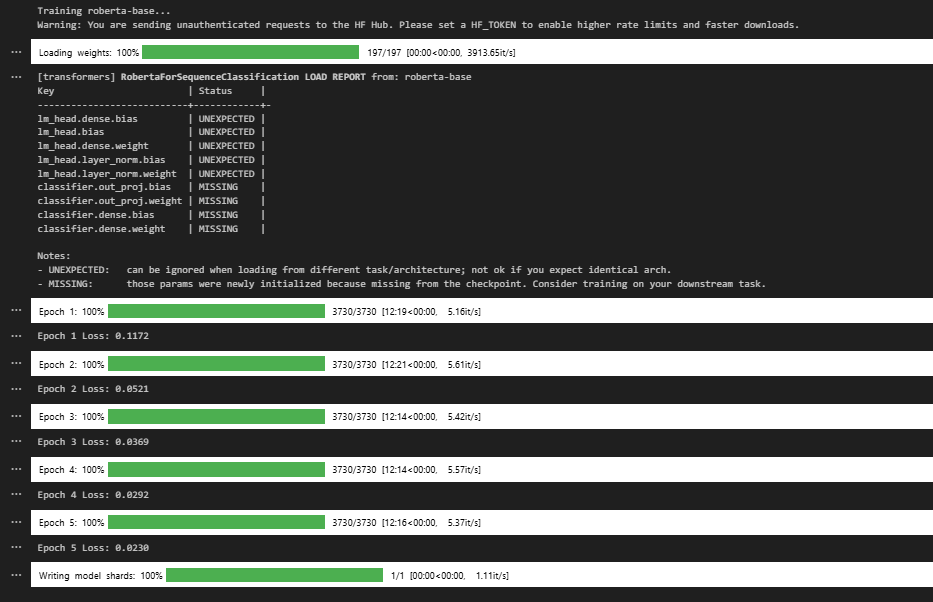

In [ ]:
# 2. Train & Save XLM-RoBERTa
xlm_model, xlm_tok = train_model('xlm-roberta-base', train_df, val_df, epochs=5)
xlm_model.save_pretrained('saved_models/xlm_roberta')
xlm_tok.save_pretrained('saved_models/xlm_roberta')
del xlm_model, xlm_tok
gc.collect(); torch.cuda.empty_cache()

# sudah di save model XLM-RoBERTa
![Screenshot 2026-05-07 200841.png](<attachment:Screenshot 2026-05-07 200841.png>)
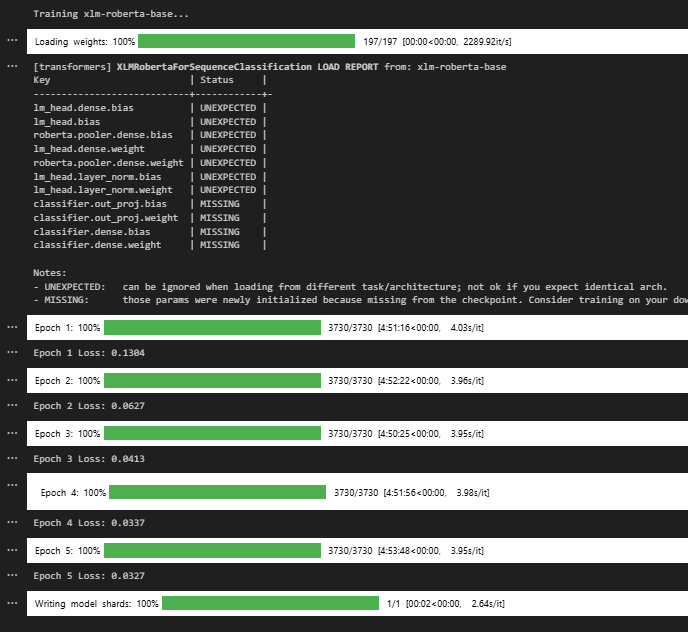

In [ ]:
# 3. Train & Save DeBERTa
deberta_model, deberta_tok = train_model('microsoft/deberta-base', train_df, val_df, epochs=5)
deberta_model.save_pretrained('saved_models/deberta')
deberta_tok.save_pretrained('saved_models/deberta')
del deberta_model, deberta_tok
gc.collect(); torch.cuda.empty_cache()

# Training dilakukan di google collab biar cepat, tidak seperti model sebelumnya yg memerlukan waktu 25 jam
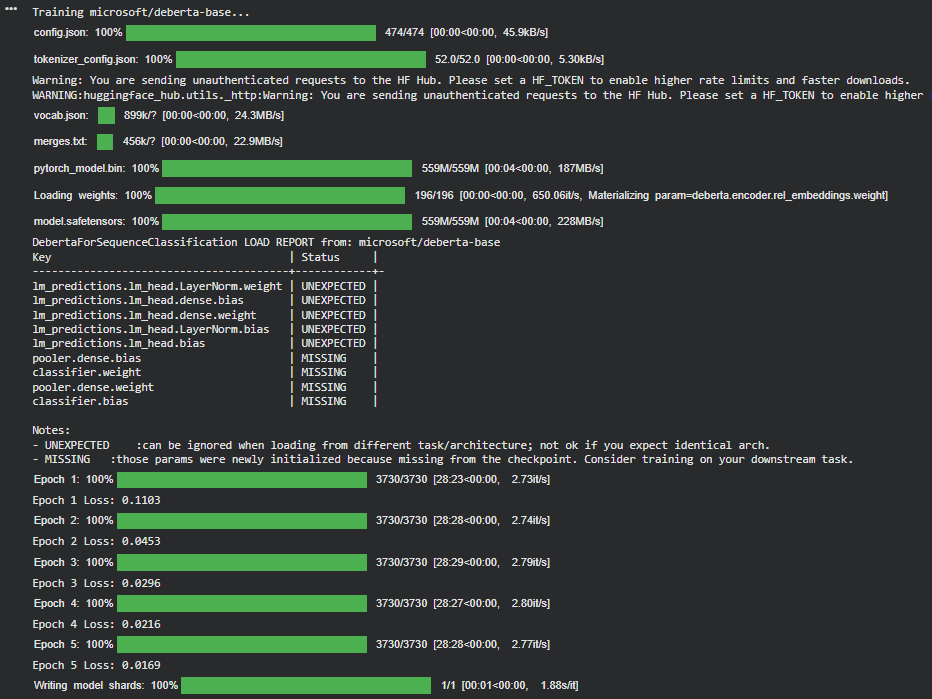

# Sudah di save model distilbert

In [ ]:
# 4. Train & Save DistilBERT
distilbert_model, distilbert_tok = train_model('distilbert-base-uncased', train_df, val_df, epochs=5)
distilbert_model.save_pretrained('saved_models/distilbert')
distilbert_tok.save_pretrained('saved_models/distilbert')
del distilbert_model, distilbert_tok
gc.collect(); torch.cuda.empty_cache()

print("\n=== SEMUA MODEL SELESAI DILATIH & DISIMPAN DI DISK ===")

![Screenshot 2026-05-07 200855.png](<attachment:Screenshot 2026-05-07 200855.png>)
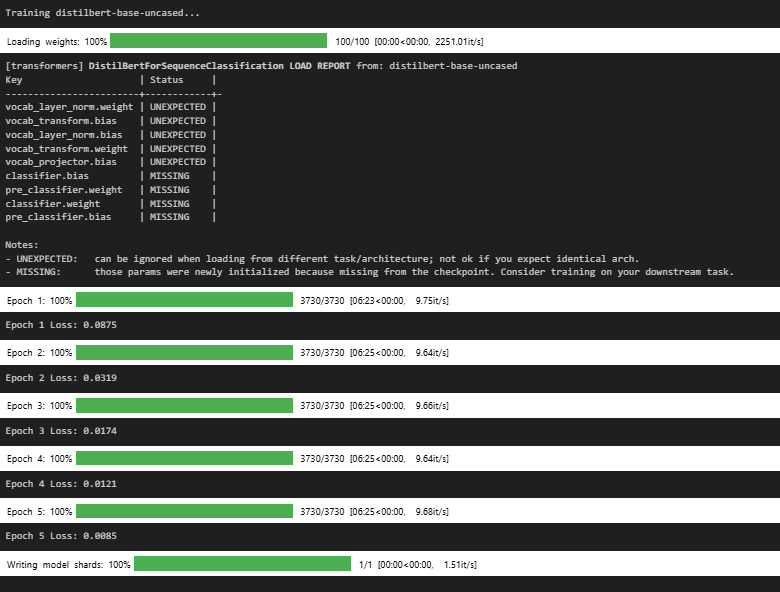

## 5. Evaluation

In [8]:
def evaluate_robustness(model, tokenizer, test_df, attack_type=None, use_defense=False):
    model.eval()
    preds, actuals = [], []
    latencies = []
    rss_scores = []
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Eval {attack_type}"):
        original_text = row['message']
        if attack_type == 'homoglyph': text = attacker.apply_homoglyph(original_text)
        elif attack_type == 'invisible': text = attacker.apply_invisible(original_text)
        elif attack_type == 'layered': text = attacker.apply_layered(original_text)
        else: text = original_text
        if use_defense:
            text = defense.reconstruct(text)
            rss = 1 - Levenshtein.distance(text, original_text)/max(len(text), len(original_text))
            rss_scores.append(rss)
        start_time = time.time()
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        latency = (time.time() - start_time) * 1000
        latencies.append(latency)
        preds.append(torch.argmax(outputs.logits).item())
        actuals.append(row['label'])
    return {'f1': f1_score(actuals, preds), 'latency': np.mean(latencies), 'rss': np.mean(rss_scores) if rss_scores else 1.0}

results = []
test_slice = test_df.head(200)

models_to_eval = [
    ('RoBERTa', 'saved_models/roberta'),
    ('XLM-RoBERTa', 'saved_models/xlm_roberta'),
    ('DeBERTa', 'saved_models/deberta'),
    ('DistilBERT', 'saved_models/distilbert')
]

for name, path in models_to_eval:
    print(f"\nEvaluating {name} from {path}...")
    m = AutoModelForSequenceClassification.from_pretrained(path).to(device)
    t = AutoTokenizer.from_pretrained(path)
    
    clean_res = evaluate_robustness(m, t, test_slice)
    layered_res = evaluate_robustness(m, t, test_slice, attack_type='layered')
    defended_res = evaluate_robustness(m, t, test_slice, attack_type='layered', use_defense=True)
    
    results.append({
        'Model': name, 'Clean F1': clean_res['f1'], 'Layered F1': layered_res['f1'],
        'RR': layered_res['f1'] / clean_res['f1'] if clean_res['f1'] > 0 else 0,
        'Defended F1': defended_res['f1'], 'RSS': defended_res['rss'], 'Latency (ms)': clean_res['latency']
    })
    
    del m, t
    gc.collect()
    torch.cuda.empty_cache()

final_df = pd.DataFrame(results)
print("\n--- FINAL COMPARISON ---")
print(final_df)



Evaluating RoBERTa from saved_models/roberta...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Eval None:   0%|          | 0/200 [00:00<?, ?it/s]

Eval layered:   0%|          | 0/200 [00:00<?, ?it/s]

Eval layered:   0%|          | 0/200 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Eval None:   0%|          | 0/200 [00:00<?, ?it/s]

Eval layered:   0%|          | 0/200 [00:00<?, ?it/s]

Eval layered:   0%|          | 0/200 [00:00<?, ?it/s]


--- FINAL COMPARISON ---
         Model  Clean F1  Layered F1        RR  Defended F1       RSS  \
0      RoBERTa  0.975610    0.430380  0.441139     0.950000  0.992450   
1  XLM-RoBERTa  1.000000    0.558140  0.558140     0.983871  0.990754   
2      DeBERTa  0.967213    0.400000  0.413559     0.967213  0.989908   
3   DistilBERT  0.983607    0.747475  0.759933     0.983607  0.990756   

   Latency (ms)  
0     26.315843  
1     18.617582  
2     52.938777  
3      9.696060  


## 6. Visualizations

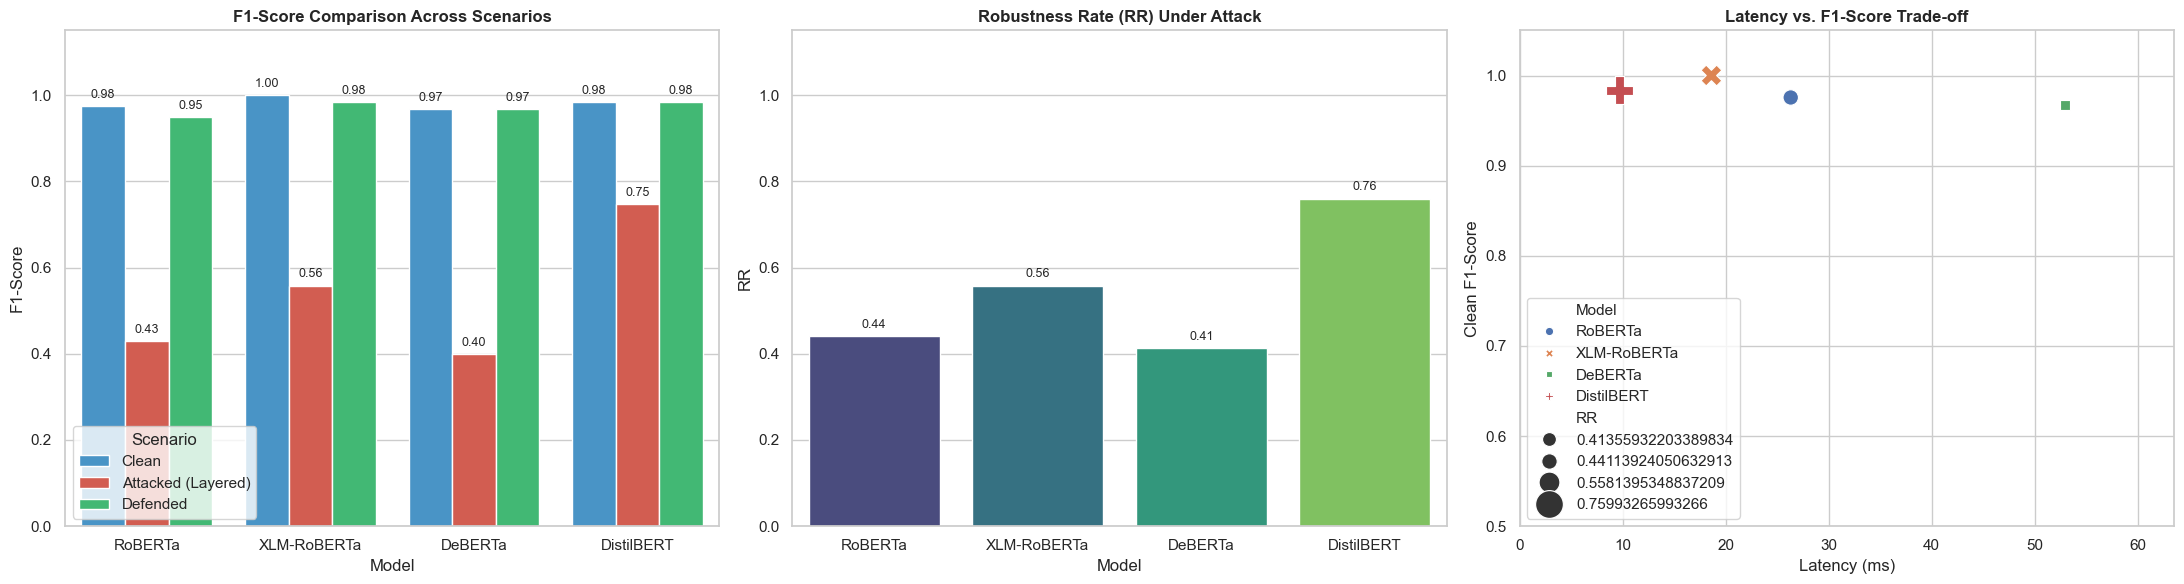

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Prepare data for plotting
plot_data = []
for index, row in final_df.iterrows():
    plot_data.append({'Model': row['Model'], 'F1-Score': row['Clean F1'], 'Scenario': 'Clean'})
    plot_data.append({'Model': row['Model'], 'F1-Score': row['Layered F1'], 'Scenario': 'Attacked (Layered)'})
    plot_data.append({'Model': row['Model'], 'F1-Score': row['Defended F1'], 'Scenario': 'Defended'})

plot_df = pd.DataFrame(plot_data)

# 6.2 Create Grid Plot with 3 charts
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Plot 1: F1-Score Comparison
ax1 = sns.barplot(
    ax=axes[0], x="Model", y="F1-Score", hue="Scenario", data=plot_df,
    palette=["#3498db", "#e74c3c", "#2ecc71"]
)
axes[0].set_title("F1-Score Comparison Across Scenarios", fontsize=12, fontweight='bold')
axes[0].set_ylim(0.0, 1.15)
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8), textcoords='offset points', fontsize=9)

# Plot 2: Robustness Rate (RR) Comparison
ax2 = sns.barplot(
    ax=axes[1], x="Model", y="RR", data=final_df, palette="viridis"
)
axes[1].set_title("Robustness Rate (RR) Under Attack", fontsize=12, fontweight='bold')
axes[1].set_ylim(0.0, 1.15)
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f"{p.get_height():.2f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8), textcoords='offset points', fontsize=9)

# Plot 3: Latency vs. Accuracy Trade-off
ax3 = sns.scatterplot(
    ax=axes[2], x="Latency (ms)", y="Clean F1", hue="Model", style="Model",
    size="RR", sizes=(100, 400), data=final_df, palette="deep"
)
axes[2].set_title("Latency vs. F1-Score Trade-off", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Clean F1-Score")
axes[2].set_xlim(0, final_df["Latency (ms)"].max() * 1.2)
axes[2].set_ylim(0.5, 1.05)

plt.tight_layout()
# Save the figure
os.makedirs('output/results', exist_ok=True)
plt.savefig('output/results/full_evaluation_plots.png', dpi=300)
plt.show()